# Phase 3 — Clustering

**Input** : `laptop_phase2.csv`  
**Output** : `laptop_phase3.csv` + `clustering_results.json` + visualisations

**Features du clustering : `price` + `ram_gb` + `storage_gb`**  
> `rating` (100 % NaN) et `reviews_count` (100 % zéro) ont été retirés dès la Phase 1.  
> `ram_gb` et `storage_gb`, extraits des titres en Phase 1, sont les features techniques fiables.  
> Les lignes sans ces features sont exclues du clustering puis ré-assignées par le plus proche centroïde.

Étapes :
1. Chargement & préparation des features
2. Normalisation (StandardScaler)
3. K-Means — choix optimal de k (Elbow + Silhouette)
4. K-Means — clustering final + interprétation
5. DBSCAN
6. PCA 2D + visualisations
7. Comparaison K-Means vs DBSCAN
8. Export

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

INPUT_PATH   = '../inputs/laptop_phase2.csv'
OUTPUT_DIR   = '../outputs/'
RANDOM_STATE = 42

print('✅ Setup terminé')

✅ Setup terminé


## 1. Chargement & préparation des features

In [18]:
df = pd.read_csv(INPUT_PATH)

print(f'Shape chargé : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head(3)

Shape chargé : (50, 13)
Colonnes : ['title', 'brand', 'price', 'price_usd', 'currency', 'platform', 'ram_gb', 'storage_gb', 'category', 'search_query', 'url', 'scraped_date', 'price_range']


,title,brand,price,price_usd,currency,platform,ram_gb,storage_gb,category,search_query,url,scraped_date,price_range
0,"Hp Laptop 15-FC0075k - Ecran FHD 15,6""- Ryzen5...",HP,5799.00,579.90,MAD,jumia,8.0,512.0,electronics,laptop,https://www.jumia.ma/hp-laptop-15-fc0075k-ecra...,2026-05-13,bas_de_gamme
1,Lenovo ThinkPad X13 Yoga Gen 1 Convertible Lap...,Lenovo,4099.00,409.90,MAD,jumia,16.0,512.0,electronics,laptop,https://www.jumia.ma/lenovo-thinkpad-x13-yoga-...,2026-05-13,bas_de_gamme
2,2025 MSI Stealth 18 HX AI Gaming Laptop 18 Inc...,MSI,39218.93,3921.89,MAD,aliexpress,64.0,2048.0,electronics,laptop,https://www.aliexpress.com/item/10050116276281...,2026-05-13,haut_de_gamme


In [19]:
# --- Vérification des features avant clustering ---
print('=== Diagnostic des features candidates ===')
for col in ['price', 'ram_gb', 'storage_gb']:
    s = df[col]
    print(f'{col:15s}  NaN={s.isna().sum():3d} ({s.isna().mean()*100:.0f}%)  '
          f'std={s.std():.2f}  min={s.min():.1f}  max={s.max():.1f}')

print()
print('→ Features retenues pour le clustering : price + ram_gb + storage_gb')
print('→ rating et reviews_count écartés (100% NaN / 100% zéro)')

=== Diagnostic des features candidates ===
price            NaN=  0 (0%)  std=9615.94  min=2602.9  max=45362.0
ram_gb           NaN= 12 (24%)  std=14.30  min=4.0  max=64.0
storage_gb       NaN= 17 (34%)  std=612.15  min=128.0  max=2048.0

→ Features retenues pour le clustering : price + ram_gb + storage_gb
→ rating et reviews_count écartés (100% NaN / 100% zéro)


In [20]:
FEATURES = ['price', 'ram_gb', 'storage_gb']

# Lignes avec les 3 features renseignées
df_cluster = df.dropna(subset=FEATURES)[FEATURES].copy()

print(f'Lignes utilisables pour le clustering : {len(df_cluster)}/{len(df)} '
      f'({len(df_cluster)/len(df)*100:.0f}%)')
print()
print('Stats des features :')
print(df_cluster.describe().round(2))

Lignes utilisables pour le clustering : 33/50 (66%)

Stats des features :
          price  ram_gb  storage_gb
count     33.00   33.00       33.00
mean   14243.76   26.55     1074.42
std    10164.67   14.83      612.15
min     2602.93    4.00      128.00
25%     7421.66   16.00      512.00
50%    11952.24   32.00     1024.00
75%    17757.60   32.00     1024.00
max    45362.04   64.00     2048.00


## 2. Normalisation (StandardScaler)

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print('Données normalisées (mean ≈ 0, std ≈ 1) :')
print(pd.DataFrame(X_scaled, columns=FEATURES).describe().round(3))

# Index des lignes incluses dans le clustering
cluster_idx = df_cluster.index

Données normalisées (mean ≈ 0, std ≈ 1) :
        price  ram_gb  storage_gb
count  33.000  33.000      33.000
mean    0.000  -0.000      -0.000
std     1.016   1.016       1.016
min    -1.163  -1.544      -1.570
25%    -0.682  -0.722      -0.933
50%    -0.229   0.374      -0.084
75%     0.351   0.374      -0.084
max     3.109   2.565       1.615


## 3. K-Means — Choix optimal de k (Elbow + Silhouette)

In [22]:
K_RANGE = range(2, 11)

inertias    = []
silhouettes = []
db_scores   = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f'k={k}  |  inertie={km.inertia_:,.1f}  |  silhouette={silhouettes[-1]:.4f}  |  DB={db_scores[-1]:.4f}')

k=2  |  inertie=67.0  |  silhouette=0.4982  |  DB=0.7227
k=3  |  inertie=50.2  |  silhouette=0.4932  |  DB=0.6851
k=4  |  inertie=28.7  |  silhouette=0.5055  |  DB=0.6316
k=5  |  inertie=22.0  |  silhouette=0.4959  |  DB=0.6569
k=6  |  inertie=20.5  |  silhouette=0.3103  |  DB=0.7965
k=7  |  inertie=10.9  |  silhouette=0.4157  |  DB=0.6492
k=8  |  inertie=7.3  |  silhouette=0.5125  |  DB=0.4630
k=9  |  inertie=6.5  |  silhouette=0.4741  |  DB=0.6344
k=10  |  inertie=5.0  |  silhouette=0.4826  |  DB=0.5779


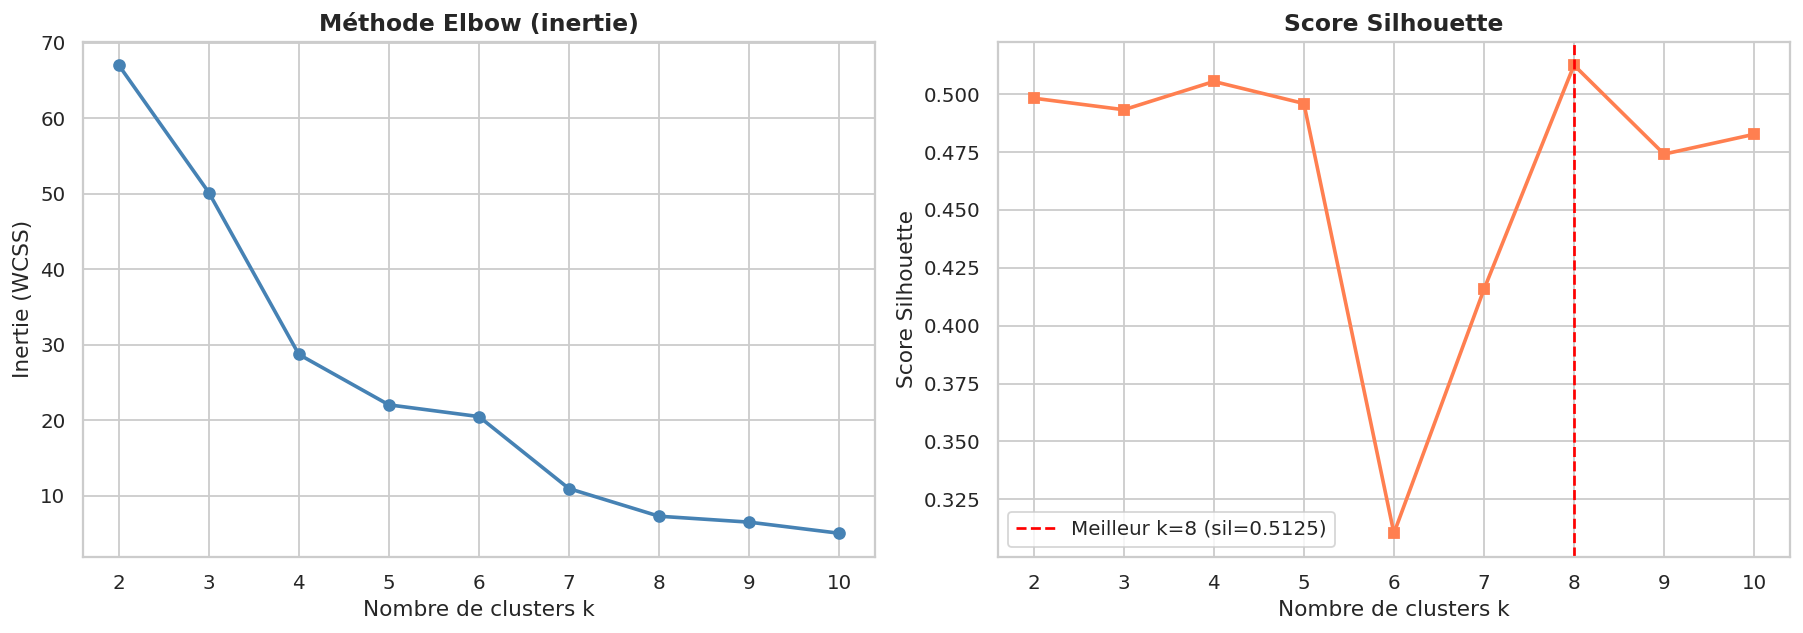


✅ Meilleur k selon Silhouette : k=8


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Méthode Elbow (inertie)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nombre de clusters k'); axes[0].set_ylabel('Inertie (WCSS)')
axes[0].set_xticks(list(K_RANGE))

# Silhouette
best_k_sil = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].plot(list(K_RANGE), silhouettes, 's-', color='coral', linewidth=2)
axes[1].axvline(best_k_sil, color='red', linestyle='--', linewidth=1.5,
                label=f'Meilleur k={best_k_sil} (sil={max(silhouettes):.4f})')
axes[1].set_title('Score Silhouette', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de clusters k'); axes[1].set_ylabel('Score Silhouette')
axes[1].set_xticks(list(K_RANGE)); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase3_elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ Meilleur k selon Silhouette : k={best_k_sil}')

## 4. K-Means — Clustering final

In [24]:
K_FINAL = 3  # 3 gammes métier : bas / milieu / haut de gamme

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init='auto')
labels_cluster = km_final.fit_predict(X_scaled)

# Assigner les clusters aux lignes incluses
df.loc[cluster_idx, 'cluster_kmeans'] = labels_cluster

# Ré-assigner les lignes sans ram_gb ou storage_gb au cluster le plus proche (sur price seul)
missing_feat_idx = df[df['ram_gb'].isna() | df['storage_gb'].isna()].index
if len(missing_feat_idx) > 0:
    price_scaled = (df.loc[missing_feat_idx, 'price'].values - scaler.mean_[0]) / scaler.scale_[0]
    centers_price = km_final.cluster_centers_[:, 0]
    assigned = np.argmin(np.abs(price_scaled[:, None] - centers_price[None, :]), axis=1)
    df.loc[missing_feat_idx, 'cluster_kmeans'] = assigned
    print(f'→ {len(missing_feat_idx)} lignes sans ram_gb/storage_gb ré-assignées par prix seul')

df['cluster_kmeans'] = df['cluster_kmeans'].astype(int)

sil_final = silhouette_score(X_scaled, labels_cluster)
db_final_score = davies_bouldin_score(X_scaled, labels_cluster)

print(f'K-Means k={K_FINAL} :')
print(f'  Inertie          : {km_final.inertia_:,.2f}')
print(f'  Score Silhouette : {sil_final:.4f}')
print(f'  Davies-Bouldin   : {db_final_score:.4f}')
print()
print('Répartition :')
print(df['cluster_kmeans'].value_counts().sort_index())

→ 17 lignes sans ram_gb/storage_gb ré-assignées par prix seul
K-Means k=3 :
  Inertie          : 50.16
  Score Silhouette : 0.4932
  Davies-Bouldin   : 0.6851

Répartition :
cluster_kmeans
0    10
1    35
2     5
Name: count, dtype: int64


In [25]:
# Labellisation par prix médian croissant
cluster_stats = df.groupby('cluster_kmeans')['price'].median().sort_values()
print('Prix médian par cluster :')
print(cluster_stats)

label_map = {}
for i, cluster_id in enumerate(cluster_stats.index):
    label_map[int(cluster_id)] = ['bas_de_gamme', 'milieu_de_gamme', 'haut_de_gamme'][i]

df['cluster_kmeans_label'] = df['cluster_kmeans'].map(label_map)

print('\nLabel → cluster :')
print(label_map)
print()
print('Stats par cluster :')
print(df.groupby('cluster_kmeans_label')[['price', 'ram_gb']].agg(['median', 'mean', 'count']).round(2))

Prix médian par cluster :
cluster_kmeans
1     8527.71
0    13895.39
2    37022.06
Name: price, dtype: float64

Label → cluster :
{1: 'bas_de_gamme', 0: 'milieu_de_gamme', 2: 'haut_de_gamme'}

Stats par cluster :
                         price                 ram_gb             
                        median      mean count median   mean count
cluster_kmeans_label                                              
bas_de_gamme           8527.71  10278.98    35   16.0  22.14    28
haut_de_gamme         37022.06  37023.37     5   32.0  42.67     3
milieu_de_gamme       13895.39  14052.78    10   24.0  30.86     7


## 5. DBSCAN

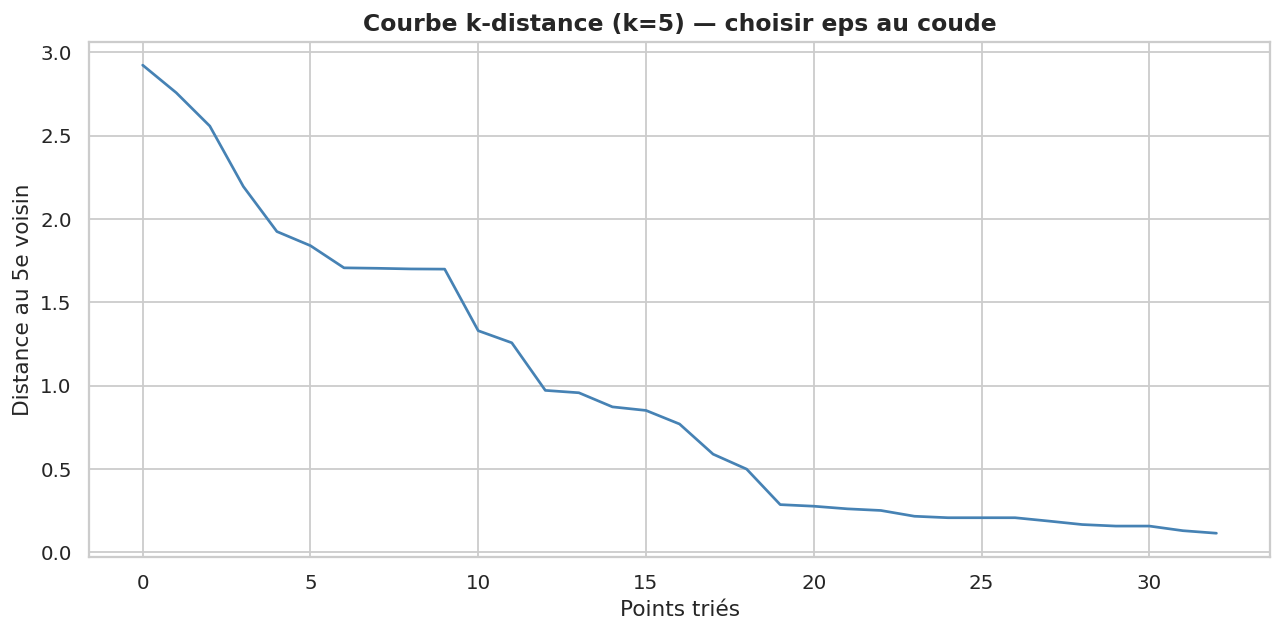

→ Observer le coude pour choisir eps ci-dessous


In [26]:
MIN_SAMPLES = 5

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color='steelblue', linewidth=1.5)
ax.set_title(f'Courbe k-distance (k={MIN_SAMPLES}) — choisir eps au coude',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Points triés'); ax.set_ylabel(f'Distance au {MIN_SAMPLES}e voisin')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase3_dbscan_kdistance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('→ Observer le coude pour choisir eps ci-dessous')

In [27]:
EPS_VALUES = [0.3, 0.5, 0.7, 1.0, 1.5]

print(f'{"eps":>6}  {"n_clusters":>10}  {"n_bruit":>8}  {"silhouette":>11}')
print('-' * 42)

best_eps = 0.5
best_sil_db = -1

for eps in EPS_VALUES:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X_scaled)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_no = (labels == -1).sum()
    if n_cl >= 2 and n_no < len(labels):
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask])
        if sil > best_sil_db:
            best_sil_db = sil; best_eps = eps
    else:
        sil = float('nan')
    print(f'{eps:>6.1f}  {n_cl:>10}  {n_no:>8}  {sil:>11.4f}')

print(f'\n→ Meilleur eps retenu : {best_eps}  (silhouette={best_sil_db:.4f})')

   eps  n_clusters   n_bruit   silhouette
------------------------------------------
   0.3           2        18       0.8620
   0.5           2        18       0.8620
   0.7           2        16       0.8015
   1.0           2        11       0.5828
   1.5           1        10          nan

→ Meilleur eps retenu : 0.3  (silhouette=0.8620)


In [28]:
db_final = DBSCAN(eps=best_eps, min_samples=MIN_SAMPLES)
dbscan_labels = db_final.fit_predict(X_scaled)

# Assigner aux lignes incluses
df.loc[cluster_idx, 'cluster_dbscan'] = dbscan_labels
df.loc[missing_feat_idx, 'cluster_dbscan'] = -1  # lignes sans ram → bruit par défaut

df['cluster_dbscan'] = df['cluster_dbscan'].fillna(-1).astype(int)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = (dbscan_labels == -1).sum()

print(f'DBSCAN (eps={best_eps}, min_samples={MIN_SAMPLES}) :')
print(f'  Clusters : {n_clusters_db}')
print(f'  Bruit    : {n_noise_db} ({n_noise_db/len(X_scaled)*100:.1f}%)')
print()
print(df['cluster_dbscan'].value_counts().sort_index())

DBSCAN (eps=0.3, min_samples=5) :
  Clusters : 2
  Bruit    : 18 (54.5%)

cluster_dbscan
-1    35
 0     9
 1     6
Name: count, dtype: int64


## 6. PCA 2D + Visualisations

In [29]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

df.loc[cluster_idx, 'pca_x'] = X_pca[:, 0]
df.loc[cluster_idx, 'pca_y'] = X_pca[:, 1]

var_ratio = pca.explained_variance_ratio_
print(f'PC1 : {var_ratio[0]*100:.1f}%  |  PC2 : {var_ratio[1]*100:.1f}%  |  Total : {sum(var_ratio)*100:.1f}%')

print('\nLoadings (contribution des features aux composantes) :')
df_loadings = pd.DataFrame(pca.components_.T, index=FEATURES, columns=['PC1', 'PC2'])
print(df_loadings.round(4))

PC1 : 66.9%  |  PC2 : 22.3%  |  Total : 89.3%

Loadings (contribution des features aux composantes) :
               PC1     PC2
price       0.5079  0.8357
ram_gb      0.6280 -0.1934
storage_gb  0.5896 -0.5140


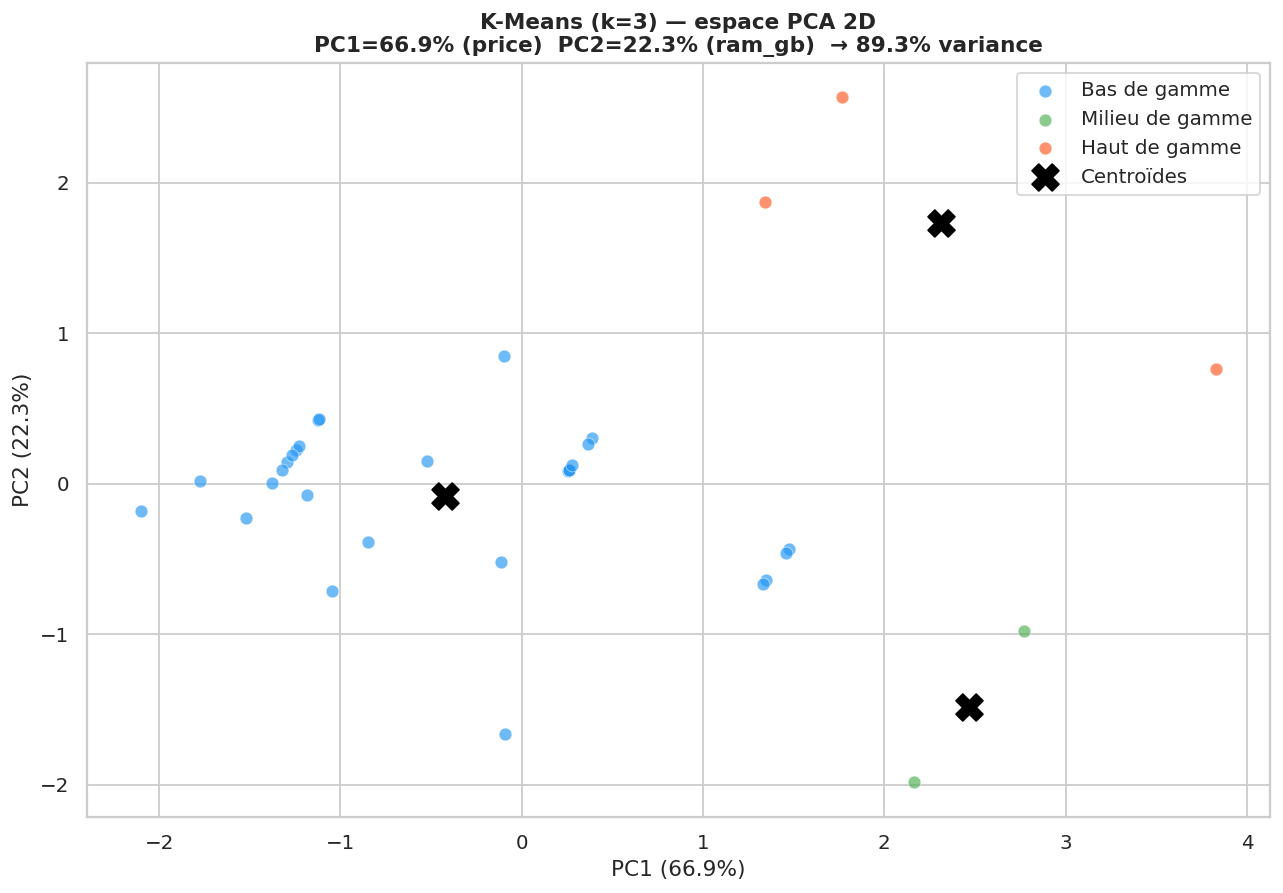

✅ phase3_kmeans_pca.png


In [30]:
# Visualisation K-Means
PALETTE_KM  = {0: '#4CAF50', 1: '#2196F3', 2: '#FF5722'}
label_names = {'bas_de_gamme': 'Bas de gamme', 'milieu_de_gamme': 'Milieu de gamme', 'haut_de_gamme': 'Haut de gamme'}

df_pca = df.dropna(subset=['pca_x', 'pca_y'])

fig, ax = plt.subplots(figsize=(10, 7))
for cluster_id, label in label_map.items():
    mask = df_pca['cluster_kmeans'] == cluster_id
    ax.scatter(df_pca.loc[mask, 'pca_x'], df_pca.loc[mask, 'pca_y'],
               c=PALETTE_KM.get(cluster_id, 'gray'),
               label=label_names.get(label, label),
               alpha=0.65, s=50, edgecolors='white', linewidths=0.4)

centers_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           marker='X', s=220, c='black', zorder=5, label='Centroïdes')

ax.set_title(f'K-Means (k={K_FINAL}) — espace PCA 2D\n'
             f'PC1={var_ratio[0]*100:.1f}% (price)  PC2={var_ratio[1]*100:.1f}% (ram_gb)  '
             f'→ {sum(var_ratio)*100:.1f}% variance',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase3_kmeans_pca.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase3_kmeans_pca.png')

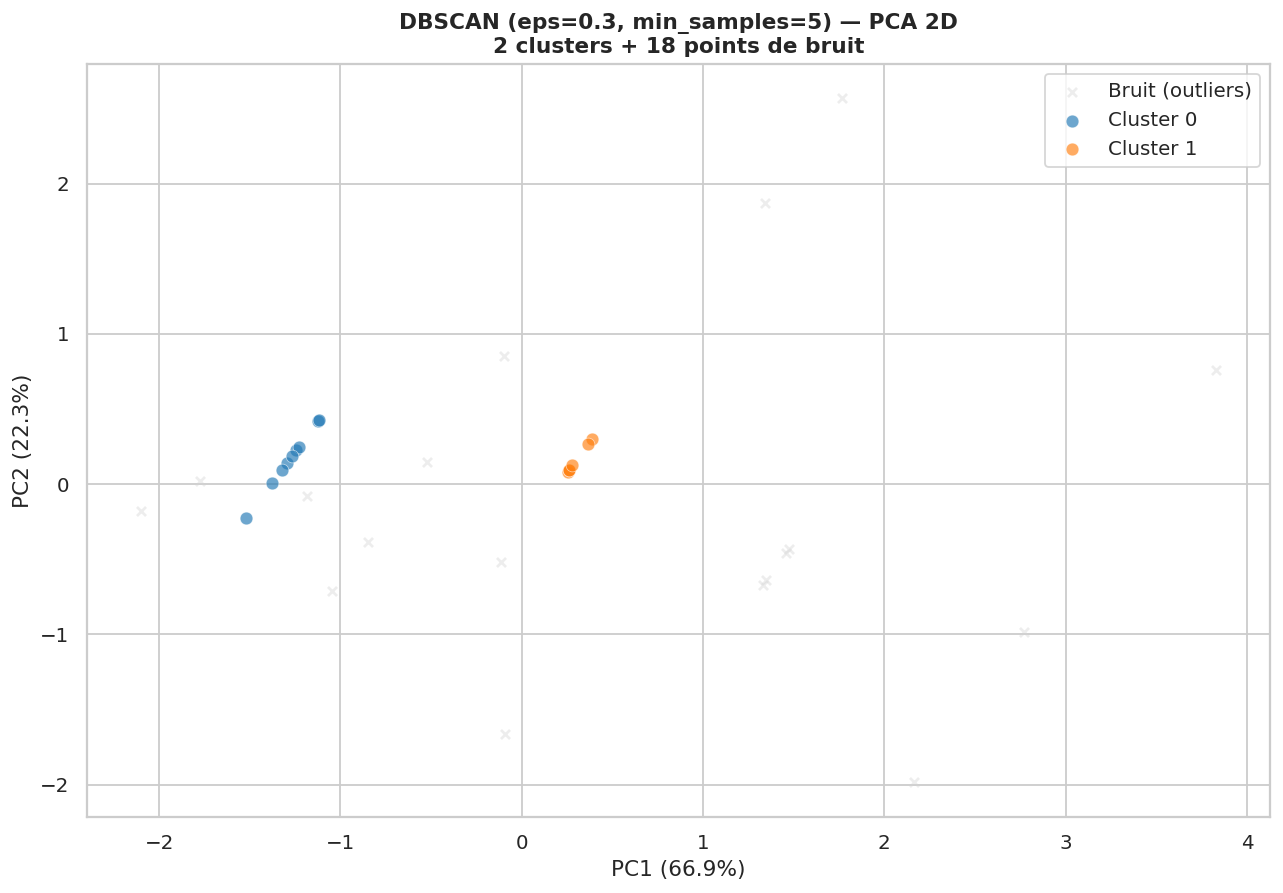

✅ phase3_dbscan_pca.png


In [31]:
# Visualisation DBSCAN
df_pca_db = df.dropna(subset=['pca_x', 'pca_y'])
unique_labels = sorted(df_pca_db['cluster_dbscan'].unique())
palette_db = sns.color_palette('tab10', max(len(unique_labels) - 1, 1))

fig, ax = plt.subplots(figsize=(10, 7))
color_idx = 0
for lbl in unique_labels:
    mask = df_pca_db['cluster_dbscan'] == lbl
    if lbl == -1:
        ax.scatter(df_pca_db.loc[mask, 'pca_x'], df_pca_db.loc[mask, 'pca_y'],
                   c='lightgray', label='Bruit (outliers)', alpha=0.4, s=25, marker='x')
    else:
        ax.scatter(df_pca_db.loc[mask, 'pca_x'], df_pca_db.loc[mask, 'pca_y'],
                   c=[palette_db[color_idx % len(palette_db)]],
                   label=f'Cluster {lbl}', alpha=0.65, s=50,
                   edgecolors='white', linewidths=0.4)
        color_idx += 1

ax.set_title(f'DBSCAN (eps={best_eps}, min_samples={MIN_SAMPLES}) — PCA 2D\n'
             f'{n_clusters_db} clusters + {n_noise_db} points de bruit',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase3_dbscan_pca.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase3_dbscan_pca.png')

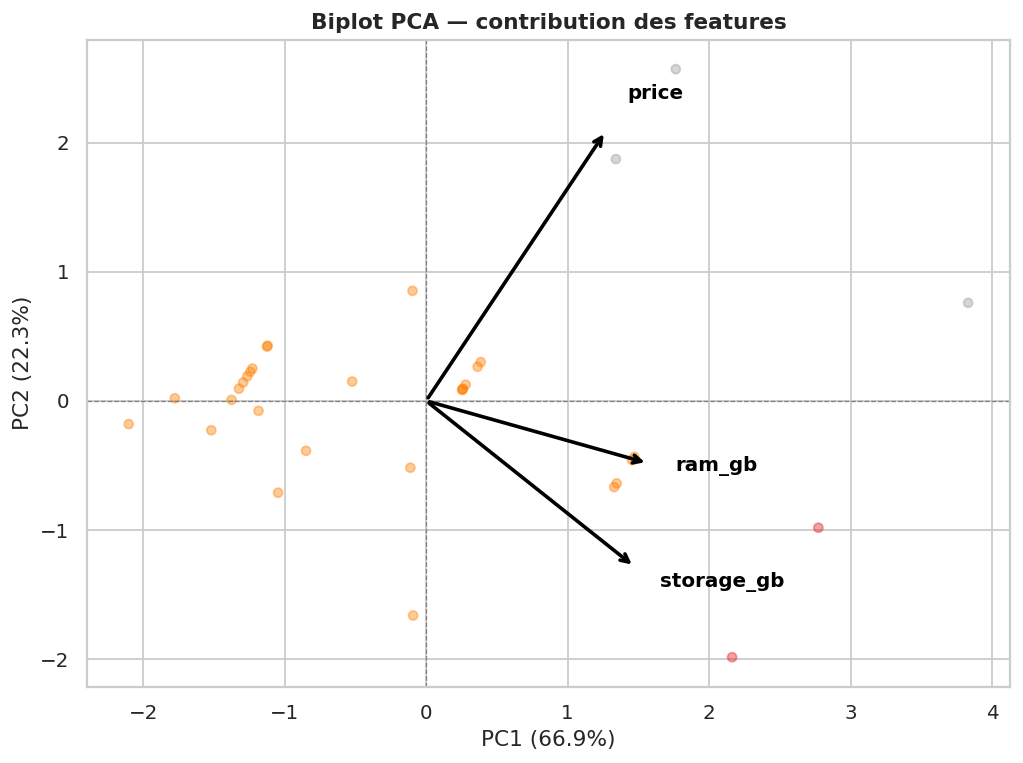

✅ phase3_pca_biplot.png


In [32]:
# Biplot PCA
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_pca['pca_x'], df_pca['pca_y'],
           c=df_pca['cluster_kmeans'], cmap='Set1', alpha=0.4, s=25)
loadings = pca.components_.T
scale = 2.5
for i, feature in enumerate(FEATURES):
    ax.annotate('', xy=(loadings[i,0]*scale, loadings[i,1]*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(loadings[i,0]*scale*1.12, loadings[i,1]*scale*1.12,
            feature, fontsize=11, fontweight='bold', color='black')
ax.set_title('Biplot PCA — contribution des features', fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase3_pca_biplot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase3_pca_biplot.png')

## 7. Comparaison & Interprétation

In [33]:
print('=== PROFIL DES CLUSTERS K-MEANS ===')
profile_km = df.groupby('cluster_kmeans_label').agg(
    count        =('price',      'count'),
    prix_min     =('price',      'min'),
    prix_median  =('price',      'median'),
    prix_max     =('price',      'max'),
    prix_moyen   =('price',      'mean'),
    ram_median   =('ram_gb',     'median'),
    ram_moyen    =('ram_gb',     'mean'),
    storage_median=('storage_gb','median'),
    storage_moyen =('storage_gb','mean')
).round(2)
print(profile_km.to_string())

=== PROFIL DES CLUSTERS K-MEANS ===
                      count  prix_min  prix_median  prix_max  prix_moyen  ram_median  ram_moyen  storage_median  storage_moyen
cluster_kmeans_label                                                                                                          
bas_de_gamme             35   2602.93      8527.71  22258.02    10278.98        16.0      22.14          1024.0         973.71
haut_de_gamme             5  29942.36     37022.06  45362.04    37023.37        32.0      42.67          1024.0        1365.33
milieu_de_gamme          10   6349.25     13895.39  18361.21    14052.78        24.0      30.86          2048.0        2048.00


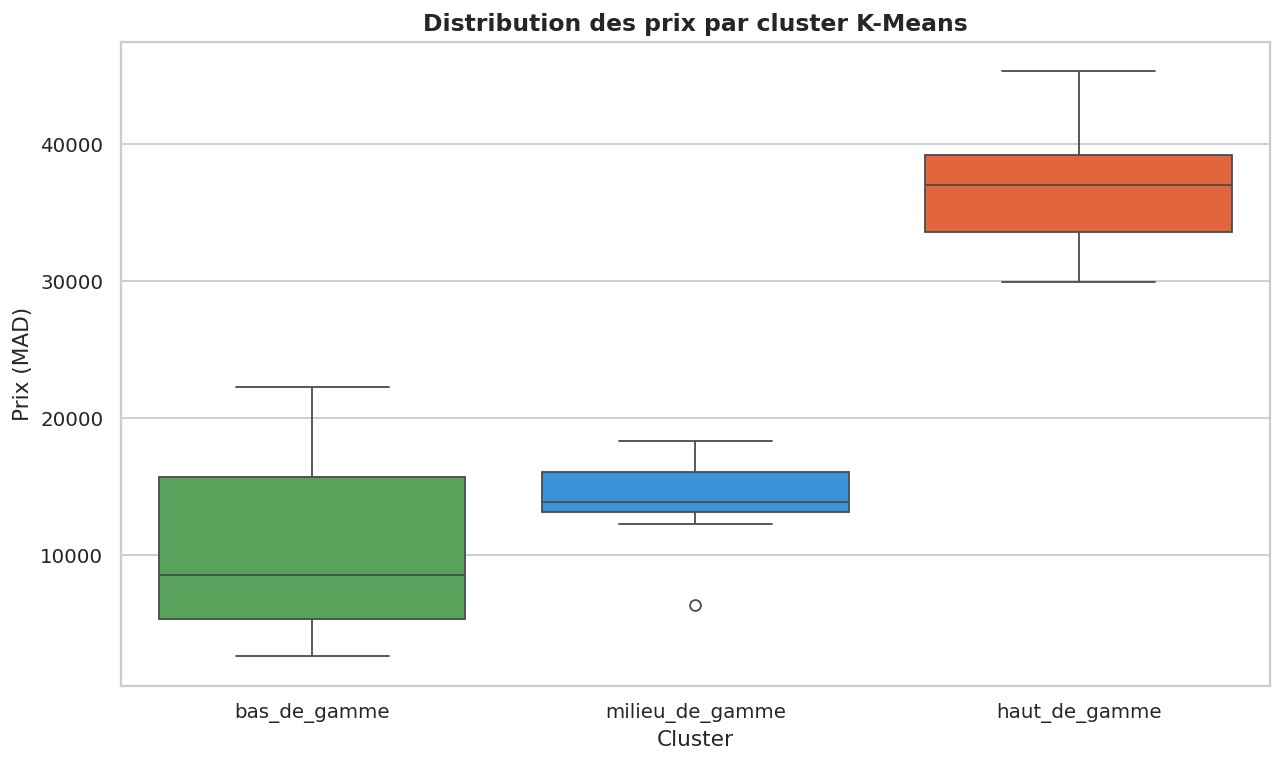

✅ phase3_boxplot_clusters.png


In [34]:
# Boxplot prix par cluster
order = [l for l in ['bas_de_gamme', 'milieu_de_gamme', 'haut_de_gamme']
         if l in df['cluster_kmeans_label'].unique()]
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='cluster_kmeans_label', y='price',
            order=order, palette=['#4CAF50', '#2196F3', '#FF5722'], ax=ax)
ax.set_title('Distribution des prix par cluster K-Means', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('Prix (MAD)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase3_boxplot_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase3_boxplot_clusters.png')

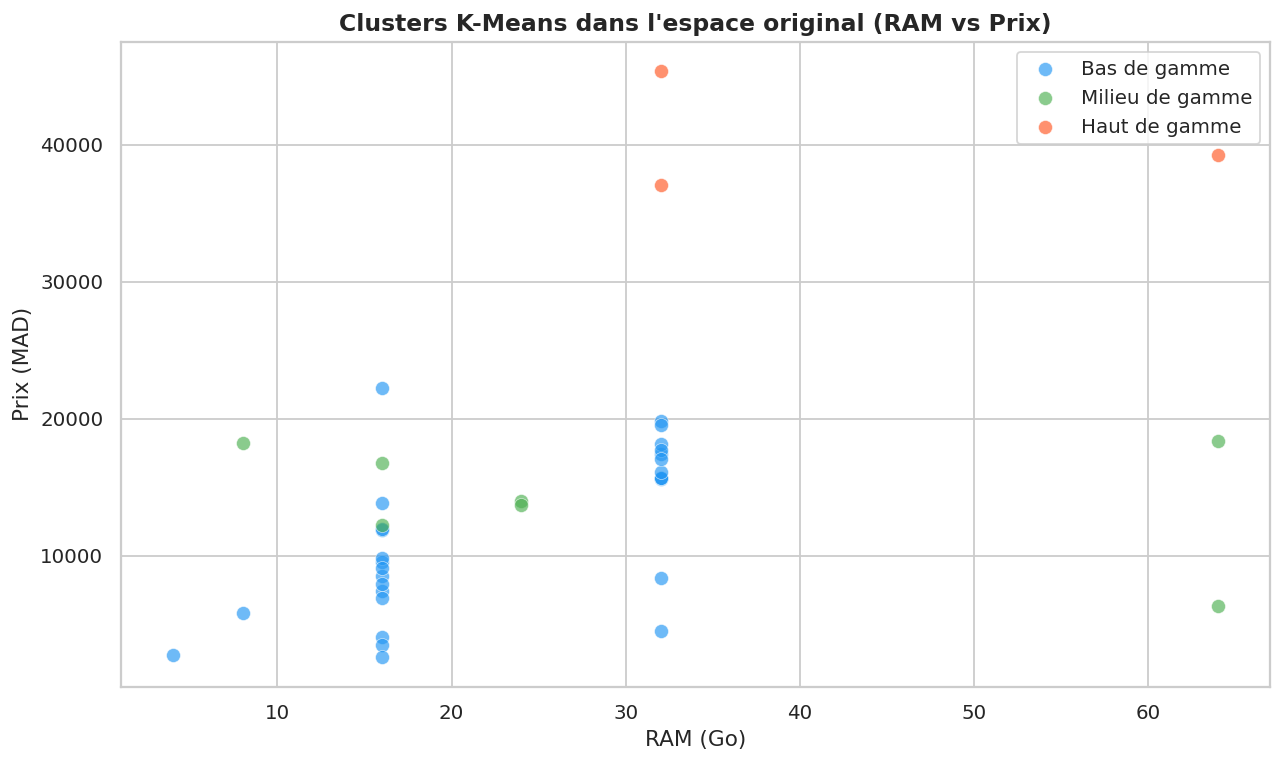

✅ phase3_clusters_ram_prix.png


In [35]:
# Scatter price vs ram coloré par cluster
df_plot = df.dropna(subset=['ram_gb'])
fig, ax = plt.subplots(figsize=(10, 6))
for cluster_id, label in label_map.items():
    mask = df_plot['cluster_kmeans'] == cluster_id
    ax.scatter(df_plot.loc[mask, 'ram_gb'], df_plot.loc[mask, 'price'],
               c=PALETTE_KM.get(cluster_id, 'gray'),
               label=label_names.get(label, label),
               alpha=0.65, s=60, edgecolors='white', linewidths=0.4)
ax.set_title('Clusters K-Means dans l\'espace original (RAM vs Prix)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('RAM (Go)'); ax.set_ylabel('Prix (MAD)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase3_clusters_ram_prix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase3_clusters_ram_prix.png')

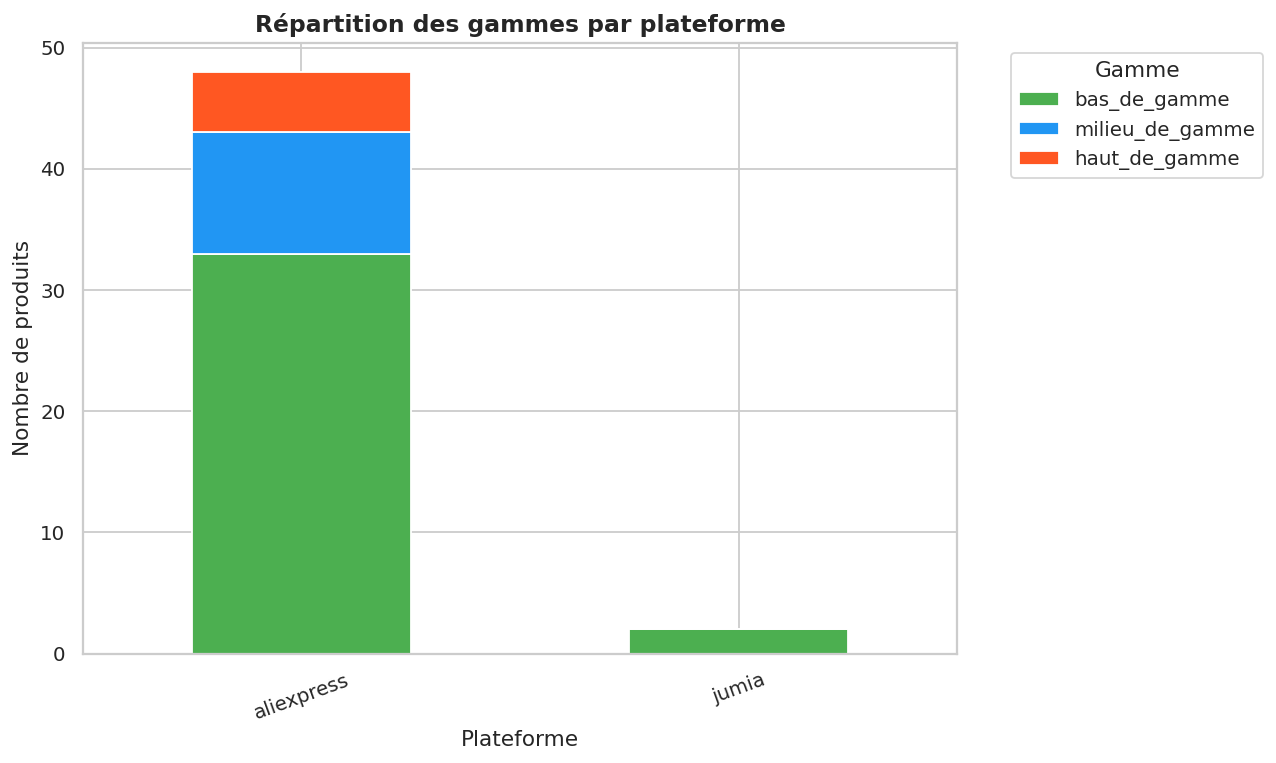

✅ phase3_clusters_par_platform.png


In [36]:
# Répartition par plateforme
fig, ax = plt.subplots(figsize=(10, 6))
ct = pd.crosstab(df['platform'], df['cluster_kmeans_label'])
ct = ct[[c for c in order if c in ct.columns]]
ct.plot(kind='bar', stacked=True, ax=ax, color=['#4CAF50', '#2196F3', '#FF5722'])
ax.set_title('Répartition des gammes par plateforme', fontsize=13, fontweight='bold')
ax.set_xlabel('Plateforme'); ax.set_ylabel('Nombre de produits')
ax.legend(title='Gamme', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase3_clusters_par_platform.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase3_clusters_par_platform.png')

In [37]:
# Comparaison K-Means vs DBSCAN
print('=== COMPARAISON K-MEANS vs DBSCAN ===')
mask_valid = dbscan_labels != -1
sil_db = silhouette_score(X_scaled[mask_valid], dbscan_labels[mask_valid]) if mask_valid.sum() > 1 else float('nan')

print(f"{'Méthode':<15} {'k/clusters':>10} {'Silhouette':>12} {'Bruit':>8}")
print('-' * 50)
print(f"{'K-Means':<15} {K_FINAL:>10} {sil_final:>12.4f} {'N/A':>8}")
print(f"{'DBSCAN':<15} {n_clusters_db:>10} {sil_db:>12.4f} {n_noise_db:>8}")
print()
print('Notes :')
print('  - K-Means : tous les points assignés (y compris sans ram via price seul)')
print('  - DBSCAN  : points bruit (-1) = candidats outliers pour Phase 4')

=== COMPARAISON K-MEANS vs DBSCAN ===
Méthode         k/clusters   Silhouette    Bruit
--------------------------------------------------
K-Means                  3       0.4932      N/A
DBSCAN                   2       0.8620       18

Notes :
  - K-Means : tous les points assignés (y compris sans ram via price seul)
  - DBSCAN  : points bruit (-1) = candidats outliers pour Phase 4


## 8. Export

In [38]:
df.to_csv('../inputs/laptop_phase3.csv', index=False, encoding='utf-8')
print(f'✅ laptop_phase3.csv  ({df.shape})')
print(f'   Colonnes ajoutées : cluster_kmeans, cluster_kmeans_label, cluster_dbscan, pca_x, pca_y')

✅ laptop_phase3.csv  ((50, 18))
   Colonnes ajoutées : cluster_kmeans, cluster_kmeans_label, cluster_dbscan, pca_x, pca_y


In [39]:
profile_km_json = profile_km.reset_index().rename(columns={'cluster_kmeans_label': 'cluster'}).to_dict(orient='records')

clustering_meta = {
    'features_used': FEATURES,
    'features_excluded': {
        'rating': '100% NaN dans le dataset source',
        'reviews_count': '100% zéro dans le dataset source'
    },
    'kmeans': {
        'k': K_FINAL,
        'silhouette_score': round(float(sil_final), 4),
        'inertia': round(float(km_final.inertia_), 2),
        'label_map': {str(k): v for k, v in label_map.items()},
        'cluster_profiles': profile_km_json
    },
    'dbscan': {
        'eps': best_eps,
        'min_samples': MIN_SAMPLES,
        'n_clusters': n_clusters_db,
        'n_noise': int(n_noise_db),
        'silhouette_score': round(float(sil_db), 4) if not np.isnan(sil_db) else None
    },
    'pca': {
        'explained_variance_pc1': round(float(var_ratio[0]), 4),
        'explained_variance_pc2': round(float(var_ratio[1]), 4),
        'total_explained': round(float(sum(var_ratio)), 4),
        'feature_loadings': df_loadings.round(4).to_dict()
    }
}

json_path = os.path.join(OUTPUT_DIR, 'clustering_results.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(clustering_meta, f, ensure_ascii=False, indent=2)

print('✅ clustering_results.json')

✅ clustering_results.json


In [40]:
print('=' * 62)
print('         RÉSUMÉ — PHASE 3 TERMINÉE')
print('=' * 62)
print(f'  Features clustering : {FEATURES}')
print(f'  Lignes clusterisées : {len(df_cluster)}/{len(df)} (ram_gb + storage_gb disponibles)')
print(f'  Algorithme 1  : K-Means (k={K_FINAL})')
print(f'  Silhouette    : {sil_final:.4f}')
print(f'  Algorithme 2  : DBSCAN (eps={best_eps}, min_samples={MIN_SAMPLES})')
print(f'  Clusters DB   : {n_clusters_db}  |  Bruit : {n_noise_db}')
print(f'  PCA variance  : {sum(var_ratio)*100:.1f}% expliquée par 2 composantes')
print('=' * 62)
print('  Fichiers produits :')
print('    📄 laptop_phase3.csv')
print('    📊 clustering_results.json')
print('    🖼  phase3_elbow_silhouette.png')
print('    🖼  phase3_dbscan_kdistance.png')
print('    🖼  phase3_kmeans_pca.png')
print('    🖼  phase3_dbscan_pca.png')
print('    🖼  phase3_pca_biplot.png')
print('    🖼  phase3_boxplot_clusters.png')
print('    🖼  phase3_clusters_ram_prix.png')
print('    🖼  phase3_clusters_par_platform.png')
print('=' * 62)
print('  ➡  Prochain input pour Phase 4 : laptop_phase3.csv')
print('     (cluster_dbscan == -1 → candidats outliers)')

         RÉSUMÉ — PHASE 3 TERMINÉE
  Features clustering : ['price', 'ram_gb', 'storage_gb']
  Lignes clusterisées : 33/50 (ram_gb + storage_gb disponibles)
  Algorithme 1  : K-Means (k=3)
  Silhouette    : 0.4932
  Algorithme 2  : DBSCAN (eps=0.3, min_samples=5)
  Clusters DB   : 2  |  Bruit : 18
  PCA variance  : 89.3% expliquée par 2 composantes
  Fichiers produits :
    📄 laptop_phase3.csv
    📊 clustering_results.json
    🖼  phase3_elbow_silhouette.png
    🖼  phase3_dbscan_kdistance.png
    🖼  phase3_kmeans_pca.png
    🖼  phase3_dbscan_pca.png
    🖼  phase3_pca_biplot.png
    🖼  phase3_boxplot_clusters.png
    🖼  phase3_clusters_ram_prix.png
    🖼  phase3_clusters_par_platform.png
  ➡  Prochain input pour Phase 4 : laptop_phase3.csv
     (cluster_dbscan == -1 → candidats outliers)
